# Zomato — Machine Learning: Dự đoán Đơn Giá trị cao

Xây dựng model Random Forest Classifier dự đoán 1 đơn hàng có thuộc nhóm giá trị cao hay không (dựa trên Bill subtotal, trước khuyến mãi), dùng các yếu tố ngữ cảnh (nhà hàng, khu vực, thời gian, khuyến mãi, thời gian vận hành).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import shap

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 50)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ĐƯỜNG DẪN

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().resolve().parent
CLEAN_PATH = BASE_DIR / 'data' / 'clean' / 'zomato_clean.csv'
CHARTS_DIR = BASE_DIR / 'outputs' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. ĐỌC DỮ LIỆU ĐÃ LÀM SẠCH

In [3]:
df = pd.read_csv(CLEAN_PATH, parse_dates=['Order Placed At'])
df['has_discount'] = df['has_discount'].astype(bool).astype(int)
print("Shape dữ liệu:", df.shape)

# ------------------------------------------------------------
# 2. TẠO BIẾN MỤC TIÊU: ĐƠN GIÁ TRỊ CAO HAY THẤP
#    Dùng Bill subtotal (giá trị TRƯỚC khuyến mãi) để tránh việc
#    has_discount/total_discount "lộ đáp án" (data leakage)
# ------------------------------------------------------------
median_subtotal = df['Bill subtotal'].median()
df['high_value'] = (df['Bill subtotal'] > median_subtotal).astype(int)
print(f"\nNgưỡng median Bill subtotal: ₹{median_subtotal:,.0f}")
print(f"Phân bố target: {df['high_value'].value_counts().to_dict()} "
      f"(0 = giá trị thấp, 1 = giá trị cao)")

Shape dữ liệu: (21321, 27)

Ngưỡng median Bill subtotal: ₹629
Phân bố target: {0: 10716, 1: 10605} (0 = giá trị thấp, 1 = giá trị cao)


## 3. CHỌN FEATURES (KHÔNG DÙNG Bill subtotal/Total/total_discount)

In [4]:
feature_cols_categorical = ['Restaurant name', 'Subzone', 'order_dayofweek']
feature_cols_numeric = ['order_hour', 'distance_km', 'has_discount',
                         'KPT duration (minutes)', 'Rider wait time (minutes)']

model_df = df[feature_cols_categorical + feature_cols_numeric + ['high_value']].dropna()
print(f"\nSố dòng dùng để train (sau khi bỏ dòng thiếu dữ liệu): {len(model_df)} / {len(df)}")


Số dòng dùng để train (sau khi bỏ dòng thiếu dữ liệu): 20963 / 21321


## 4. MÃ HÓA BIẾN PHÂN LOẠI

In [5]:
for col in feature_cols_categorical:
    le = LabelEncoder()
    model_df[col + '_enc'] = le.fit_transform(model_df[col])

feature_cols_final = [c + '_enc' for c in feature_cols_categorical] + feature_cols_numeric
X = model_df[feature_cols_final]
y = model_df['high_value']

## 5. CHIA TRAIN/TEST

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} dòng | Test: {len(X_test)} dòng")


Train: 16770 dòng | Test: 4193 dòng


## 6. HUẤN LUYỆN MODEL

In [7]:
model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

## 7. ĐÁNH GIÁ MODEL


=== KẾT QUẢ MODEL ZOMATO ===
Accuracy:  0.687
Precision: 0.683
Recall:    0.693
F1-score:  0.688


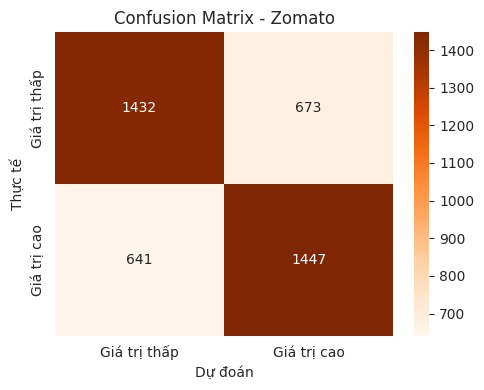

In [8]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n=== KẾT QUẢ MODEL ZOMATO ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Giá trị thấp', 'Giá trị cao'],
            yticklabels=['Giá trị thấp', 'Giá trị cao'])
plt.title('Confusion Matrix - Zomato')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_confusion_matrix_zomato.png', dpi=120)
plt.show()
plt.close()

## 8. FEATURE IMPORTANCE


=== Feature Importance (Zomato) ===
KPT duration (minutes)       0.503909
Restaurant name_enc          0.111694
has_discount                 0.102627
Rider wait time (minutes)    0.083271
distance_km                  0.072355
order_hour                   0.058786
order_dayofweek_enc          0.034244
Subzone_enc                  0.033115
dtype: float64


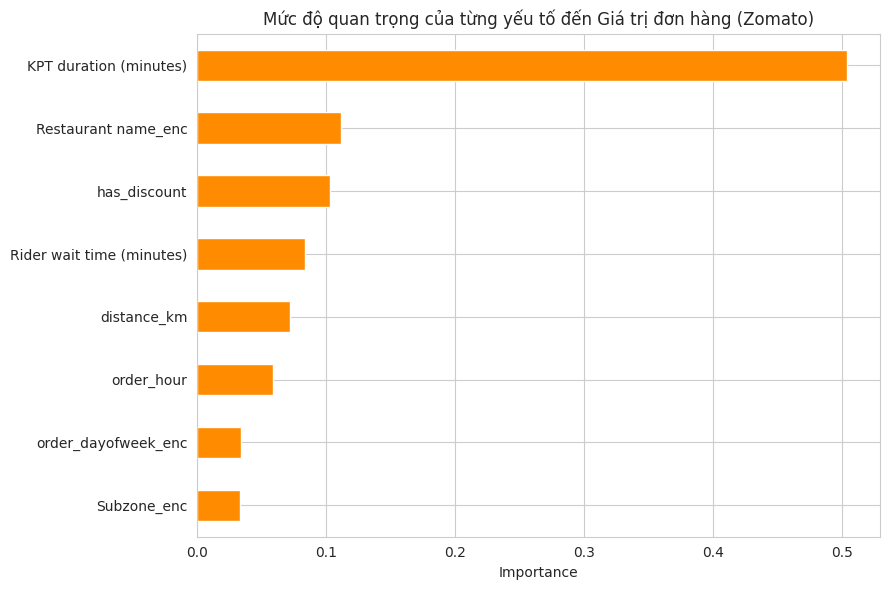

In [9]:
importance = pd.Series(model.feature_importances_, index=feature_cols_final).sort_values(ascending=False)
print("\n=== Feature Importance (Zomato) ===")
print(importance)

plt.figure(figsize=(9, 6))
importance.plot(kind='barh', color='darkorange')
plt.title('Mức độ quan trọng của từng yếu tố đến Giá trị đơn hàng (Zomato)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_feature_importance_zomato.png', dpi=120)
plt.show()
plt.close()

## 9. CROSS-VALIDATION (5-FOLD)

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("\n=== Cross-Validation (5-fold) - Zomato ===")
print(f"Accuracy từng fold: {np.round(cv_scores, 3)}")
print(f"Accuracy trung bình: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"So với Accuracy đo 1 lần trên Test set ({acc:.3f}): "
      f"{'nhất quán, đáng tin cậy' if abs(cv_scores.mean() - acc) < 0.05 else 'có chênh lệch, cần xem lại'}")


=== Cross-Validation (5-fold) - Zomato ===
Accuracy từng fold: [0.694 0.674 0.681 0.681 0.686]
Accuracy trung bình: 0.683 (+/- 0.007)
So với Accuracy đo 1 lần trên Test set (0.687): nhất quán, đáng tin cậy


## 10. SHAP VALUES - GIẢI THÍCH CHIỀU ẢNH HƯỞNG CỦA TỪNG YẾU TỐ

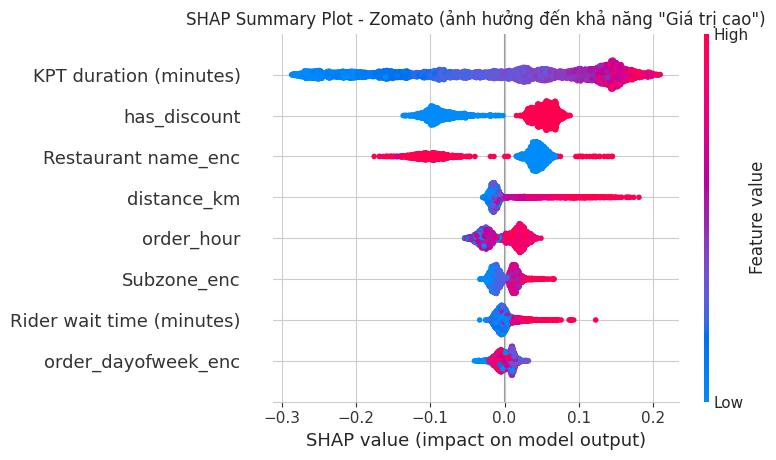


=== HOÀN TẤT MODEL ML ZOMATO (đã nâng cấp: Cross-Validation + SHAP) ===


In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap_values_high = shap_values[:, :, 1]

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_high, X_test, feature_names=feature_cols_final, show=False)
plt.title('SHAP Summary Plot - Zomato (ảnh hưởng đến khả năng "Giá trị cao")')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_shap_summary_zomato.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

print("\n=== HOÀN TẤT MODEL ML ZOMATO (đã nâng cấp: Cross-Validation + SHAP) ===")